In [33]:
%pip install cartopy

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 314.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 293.9 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
from pathlib import Path
from pyspark.sql import SparkSession
##import h5py
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyspark.sql import functions as F

Matplotlib created a temporary cache directory at /scratch/dmoncivais/job_46666460/matplotlib-f1k81rqd because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
out_dir = Path(f"/expanse/lustre/projects/uci157/{os.environ['USER']}/stead")
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Downloading to: {out_dir}")

In [3]:
path = kagglehub.dataset_download("isevilla/stanford-earthquake-dataset-stead", output_dir = str(out_dir))

print("Path to dataset files:", path)

Path to dataset files: /expanse/lustre/projects/uci157/dmoncivais/stead


In [4]:
spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "10g") \
    .config('spark.executor.instances', 15) \
    .getOrCreate()

In [5]:
df = spark.read.csv(f"{out_dir}/merge.csv", header = True)
print(type(df))

<class 'pyspark.sql.dataframe.DataFrame'>


How many observations?

In [ ]:
print("Rows:", df.count())
print("Columns:", len(df.columns))

In [ ]:
# show schema + a few rows
df.printSchema()
df.show(5, truncate=60)

Describe Columns

In [ ]:
df.describe().show(truncate=False)

Categorical and Continuous columns

In [ ]:
dtypes = dict(df.dtypes)

cat_cols = [c for c, t in df.dtypes if t == "string"]
num_cols = [c for c, t in df.dtypes if t != "string"]

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

# target column
target_col = "trace_category" if "trace_category" in df.columns else None
print("Target column:", target_col)

if target_col:
# target distribution
df.groupBy(target_col).count().orderBy(F.desc("count")).show(truncate=False)

# Categorical columns
for c in cat_cols:
print(f"\n=== {c} ===")
df.select(c).distinct().count() # just to run it
print("Distinct:", df.select(c).distinct().count())
df.groupBy(c).count().orderBy(F.desc("count")).show(10, truncate=False)

Missing values per column and Duplicates

In [ ]:
missing_exprs = []
for c, t in df.dtypes:
if t in ["double", "float", "int", "bigint", "smallint", "tinyint", "decimal", "long", "short"]:
missing_exprs.append(F.sum(F.when(F.col(c).isNull() | F.isnan(F.col(c)), 1).otherwise(0)).alias(c))
else:
missing_exprs.append(F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c))

df.select(missing_exprs).show(truncate=False)

# duplicate rows
total_rows = df.count()
unique_rows = df.dropDuplicates().count()
print("Duplicate rows:", total_rows - unique_rows)

In the next block of code there will basic information about the dataset.

In [6]:
print(f"Number of rows: {df.count()}\n")

print("Description of the data set:")
df.describe().show()

print("Data frame schema:")
df.printSchema()

print(f"Top 100 receivers based on count of readings: (receiver_code | count)")
i = 0
for row in df.groupBy('receiver_code').count().sort('count', ascending=False).collect():
    print(f"{row['receiver_code']} | {row['count']}")
    i += 1
    if i == 100:
        break

print(f"\nTotal of unique values:\n\tUnique number of network codes:{df.select('network_code').distinct().count()}\n\tUnique number of receiver_code:{df.select('receiver_code').distinct().count()}\n\tUnique number of receiver_type:{df.select('receiver_type').distinct().count()}")

Number of rows: 1268314

Description of the data set:
+-------+--------------------+-----------------+------------------+------------------+--------------------+--------------------+-----------------+---------+--------------------+-----------------+-----------------+---------+-------------------+--------------------+--------------------+-----------------------------+-----------------+-------------------+----------------+--------------+--------------------------------+------------------+---------------------------+------------------+---------------------+-----------------------+--------------------------------+-------------------+------------------+------------------+--------------------+---------------+--------------------+----------------+--------------------+
|summary|        network_code|    receiver_code|     receiver_type| receiver_latitude|  receiver_longitude|receiver_elevation_m| p_arrival_sample| p_status|            p_weight|     p_travel_sec| s_arrival_sample| s_status|     

In [7]:
coordinates = df.select("receiver_latitude", "receiver_longitude")\
              .rdd.map(lambda x: (x[0], x[1]))
coords = coordinates.collect()

latitudes = []
longitudes = []
i = 0
for row in coords:
    try:
        longitudes.append(float(row[1]))
        latitudes.append(float(row[0]))
    except Exception as e:
        continue

In [8]:
len(longitudes), len(latitudes)

(1265657, 1265657)

In this map, we can see how the stations are distributed around the world. This helps us understand why we have so many data entries in our dataset and gives us insight into how some countries are more research-focused and therefore more prone to generating relevant earthquake data. For example, countries such as Russia, Brazil, Cameroon, India, and Sudan either do not experience earthquakes frequently enough to justify extensive study, or they may not prioritize earthquake monitoring. On the other end of the spectrum, there are countries like the USA, Mexico, Chile, and the UK, where tremors are more frequent and there is greater interest in studying them.

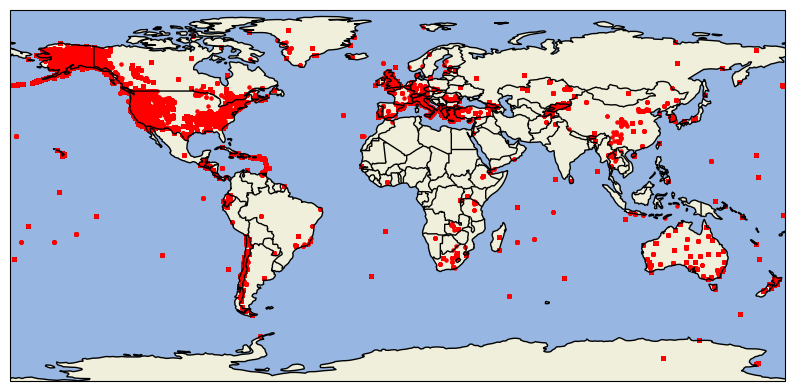

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)

ax.scatter(longitudes, latitudes,
           s=5,
           transform=ccrs.PlateCarree(),
           color = 'red'
          )

plt.show()

This project uses a ~100GB dataset, so all preprocessing will be performed in Spark using multiple CPUs.

### Handling Missing Values

**Assessment of missingness**
- For the bulk of our data, there is very little missing data. However, there are some exceptions. For the columns that we do have missing data, we will determine whether or not the data is missing at random or not. This is important to determine whether we can filter this out or not without adding bias to our analysis.

**Strategies (by feature type)**
- **Numeric fields**
  - If missing rate is very low → drop rows with nulls in critical columns.
  - If missingness is spatially/temporally structured, we will look into group-wise imputation (to get the average numbers based on several features) in order to prevent bias being added to the analysis.
- **Categorical fields**
  - Replace nulls with "Unknown" and treat as a legitimate category. However, based on our inital analysis, this does not appear to be an issue.
- **Time-series gaps**
  - For station-level features that should evolve smoothly, consider forward-fill using Spark window functions. This would be the case if a station might have had interuptions with their data.

**Spark operations to potentially use**
- `F.when(F.col(c).isNull(), 1)` (measure missingness)
- `na.drop(subset=[])`
- `na.fill({})`
- `Window.partitionBy().orderBy()` 

### Handling Data Imbalance

There is a heavy imbalance as for the vast majority of time, there is no earthquake.

- I will compute the class distribution and confirm imbalance severity.
- Mitigation options (chosen based on model and evaluation results):
  - **Class weights** (preferred when supported by the estimator)
  - We can downsample the majority class or oversample minority class using Spark sampling, depending on which is better for our accuracy.
  - We will need to adjust the decision threshold and focus on precision/recall metrics rather than accuracy

**Spark operations planned**
- `groupBy(label).count()` (measure imbalance)
- `sampleBy()` (stratified sampling)
- `withColumn("weight", ...)` (add class weights)

### Transformations (scaling, encoding, feature engineering)

To scale the numbers sufficiently for analysis:
  - `StandardScaler` (z-score)
  - `MinMaxScaler` (if StandardScalar is insufficient)

**Encoding**
- For categorical variables (if needed):
  - `StringIndexer` to convert categories to indices
  - `OneHotEncoder` to avoid unintended ordinal relationships

**Feature Engineering (domain-specific for seismic data)**
- **Temporal features** extracted from event timestamp:
  - hour-of-day, day-of-week, month/season, year
- **Correct corrdinates**
  - The corrdinate data includes depth data, so we will need to clean it and potentially separate into separate columns (between depth and actual GPS coordiates)
- **Station/region aggregation features**:
  - event counts per station/region per time window
  - mean/median magnitude per window
- **Spatial features**:
  - spatial binning via coordiates and using region IDs
- **Transforming heavy-tailed variables**:
  - consider log transforms for energy-like measures or skewed sensor metrics

**Leakage prevention (between train and test data)**
- Any features computed using time windows will be constructed using past-only information relative to the prediction timestamp.
- Train/test splitting will be time-aware when appropriate (e.g., split by date)
    -  This should prevent future information from leaking into training.

**Spark operations planned**
- `withColumn()` and built-in time functions (`year`, `month`, `dayofweek`, `hour`)
- `groupBy().agg()` for aggregations
- `Window` functions for lags/rolling features (`lag`, `avg`, `sum`)

### Spark Operations and Performance Considerations

Because the dataset is ~100GB, preprocessing will be optimized for distributed execution:
- Use column pruning (`select`) and filter early (`filter`) to reduce data volume.
  - There will be lots of opportunity for data pruning as for the vast majority of the time there is no earthquakes, so we will be able to truncate the data selectively.
- `repartition()` can be used strategically to improve parallelism, enabling us to be the most efficient with this giant dataset.
- Avoid `collect()` except on small summaries (e.g., counts, small samples) as it is very time consuming.
- Store intermediate outputs in Parquet for efficient re-use (keeping it in memory for minimal recall time)

**Core Spark functions to be used**
- DataFrame ops: `select`, `filter`, `withColumn`, `drop`, `groupBy`, `agg`, `join`
- Missingness tools: `na.fill`, `na.drop`
- Time/rolling: `Window`, `lag`, `lead`, rolling aggregates
- Others: `StringIndexer`, `OneHotEncoder`, `VectorAssembler`, `StandardScaler`, `Pipeline`